# Un sticker en la piel que lee tu nutrición en el sudor

Una gota de sudor, sin agujas y sin laboratorio, y el aparato te dice cuánto folato llevas encima. Suena a ciencia ficción — pero estos datos muestran que el sudor sí carga esa información.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Madsen et al. (2026) · *Nature Biomedical Engineering*
**DOI:** [10.1038/s41551-026-01716-5](https://doi.org/10.1038/s41551-026-01716-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-17-folato-sudor-prenatal/notebook.ipynb)

**Video:** Pendiente

## Qué hicieron

Medir folato hoy pide un pinchazo en el brazo y un laboratorio especializado. El equipo construyó otra ruta: una microcápsula que se pega a la piel, recoge microlitros de sudor limpio y los pasa a un *lab-on-a-disc* portátil — un disco que corre el ensayo completo (incubar, lavar, mezclar, detectar) y manda el dato por inalámbrico.

Lo probaron en **7 adultos sanos (3 hombres, 4 mujeres)**, no en embarazadas: lo *prenatal* es la aplicación que persiguen a futuro, no la población que validaron aquí. La pregunta que abren los datos es más básica: ¿el folato del sudor refleja el de la sangre?

In [1]:
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DATOS = '#2563EB'        # azul CaM — sudor / datos principales
COLOR_ALERTA = '#DC2626'       # rojo — suero / contraste
COLOR_SECUNDARIO = '#059669'   # emerald — validación
COLOR_REFERENCIA = '#D97706'   # amber — umbrales / ventanas
FUENTE = 'Fuente: Madsen et al. (2026), Nature Biomed. Eng. | Datos: Source Data Figs. 6-7'

def cc(x, dec=2):
    # Formato español: separador decimal con coma para los rótulos de las gráficas.
    return f'{x:.{dec}f}'.replace('.', ',')

# Estilo CaM (local -> /tmp -> GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 5 datasets (Source Data del paper)
corr = pd.read_csv('datos/correlacion_sudor_suero.csv')
cin  = pd.read_csv('datos/cinetica_temporal.csv')
seg  = pd.read_csv('datos/seguimiento_diario.csv')
val  = pd.read_csv('datos/validacion_dispositivo.csv')
cal  = pd.read_csv('datos/calibracion_sensor.csv')

print(f'Correlación sudor~suero : {len(corr)} pares, {corr.subject.nunique()} personas')
print(f'Cinética temporal       : {len(cin)} mediciones, {cin.subject.nunique()} personas')
print(f'Seguimiento diario      : {len(seg)} mediciones, {seg.subject.nunique()} personas')
print(f'Validación dispositivo  : {len(val)} pares disco vs ELISA de placa')
print(f'Calibración sensor      : {len(cal)} puntos, rango {cal.folate_ng_ml.min()}-{cal.folate_ng_ml.max()} ng/ml')

Correlación sudor~suero : 33 pares, 7 personas
Cinética temporal       : 29 mediciones, 5 personas
Seguimiento diario      : 24 mediciones, 2 personas
Validación dispositivo  : 14 pares disco vs ELISA de placa
Calibración sensor      : 7 puntos, rango 0.5-200.0 ng/ml


## ¿El sudor sabe lo que dice tu sangre?

Aquí está.

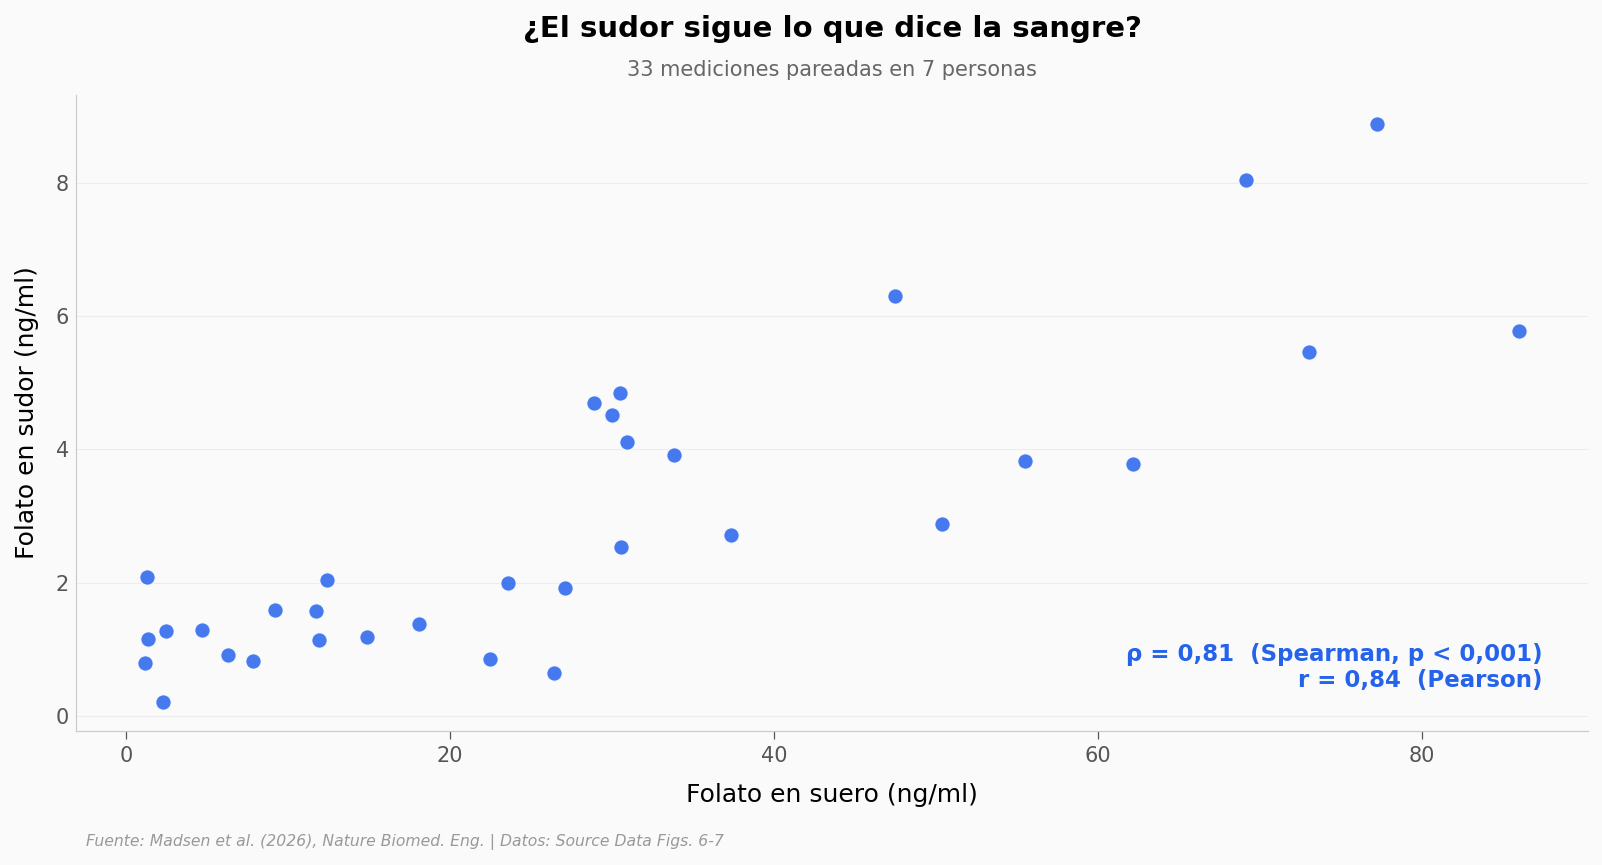

Spearman rho=0.811 (p=1.03e-08) | Pearson r=0.838 | R2=0.703


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

x = corr['serum_folate_ng_ml']
y = corr['sweat_folate_ng_ml']

# Datos sesgados (Shapiro p < 0,01) -> Spearman como estadístico principal,
# Pearson solo de apoyo (regla: rank-based por defecto si no hay normalidad).
rho, p_rho = stats.spearmanr(x, y)
r_pear, _  = stats.pearsonr(x, y)

ax.scatter(x, y, color=COLOR_DATOS, s=55, alpha=0.85,
           edgecolors='white', linewidths=0.6, zorder=5)

ax.set_xlabel('Folato en suero (ng/ml)')
ax.set_ylabel('Folato en sudor (ng/ml)')
ax.set_title('¿El sudor sigue lo que dice la sangre?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '33 mediciones pareadas en 7 personas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.97, 0.06,
        f'ρ = {cc(rho)}  (Spearman, p < 0,001)\nr = {cc(r_pear)}  (Pearson)',
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        color=COLOR_DATOS, ha='right', va='bottom')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_sudor_suero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Spearman rho={rho:.3f} (p={p_rho:.2e}) | Pearson r={r_pear:.3f} | R2={r_pear**2:.3f}')

La nube sube junta: cuando el suero tiene más folato, el sudor también. La relación es **fuerte** — Spearman ρ = 0,81, robusto aunque los datos estén sesgados (lo están: casi todas las mediciones son bajas y unas pocas muy altas). Pearson la confirma con r = 0,84.

Un detalle que cambia el diseño del aparato: el suero corre cerca de **10 veces más alto** que el sudor. Medir folato en sudor obliga a un sensor mucho más sensible que el de un análisis de sangre normal.

## Pero una foto fija no basta

Una correlación dice que sudor y sangre van de la mano en promedio. No dice si el sudor sirve para **seguir cambios en el tiempo**. Veamos qué pasa hora a hora después de tomar el suplemento.

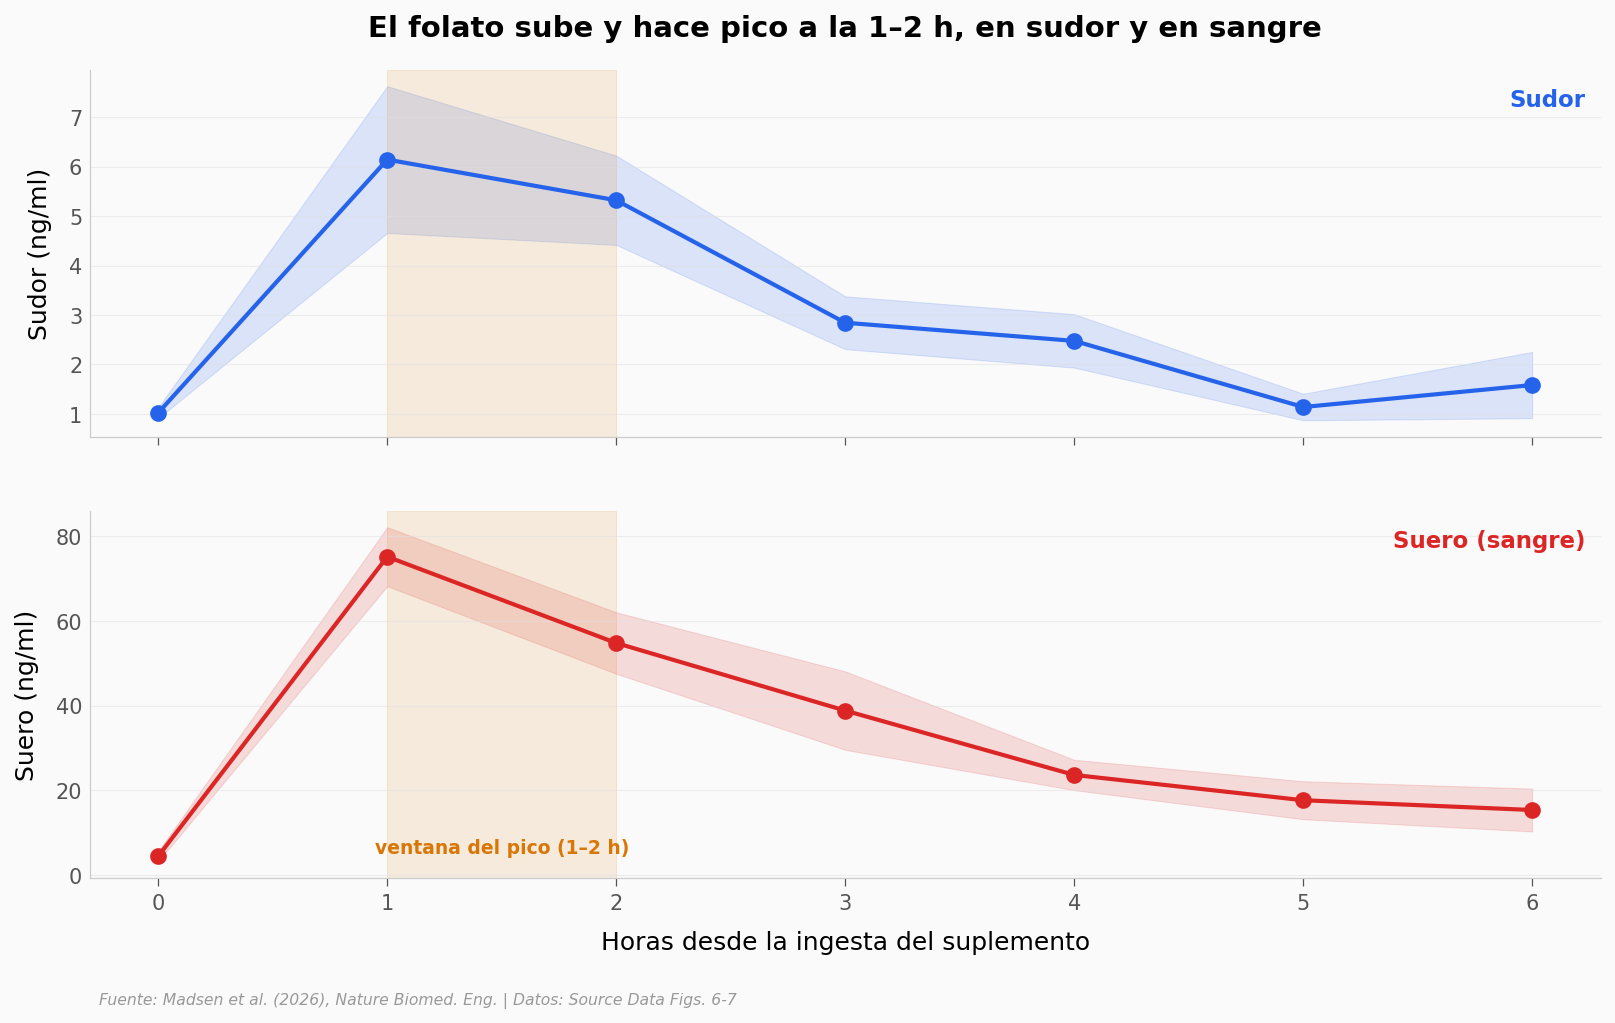

Pico sudor a las 1 h | pico suero a las 1 h


In [3]:
# Media por hora (5 personas). Suero corre ~10x más alto que sudor:
# subplots apilados que comparten el eje de tiempo, NO twinx (confunde escalas).
g = cin.groupby('time_h')
t       = g['sweat_folate_ng_ml'].mean().index.values
sweat_m = g['sweat_folate_ng_ml'].mean().values
sweat_e = g['sweat_folate_ng_ml'].sem().values
serum_m = g['serum_folate_ng_ml'].mean().values
serum_e = g['serum_folate_ng_ml'].sem().values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(t, sweat_m, color=COLOR_DATOS, lw=2, marker='o', zorder=5)
ax1.fill_between(t, sweat_m - sweat_e, sweat_m + sweat_e, color=COLOR_DATOS, alpha=0.15)
ax1.axvspan(1, 2, color=COLOR_REFERENCIA, alpha=0.12)
ax1.set_ylabel('Sudor (ng/ml)')
ax1.text(0.99, 0.90, 'Sudor', transform=ax1.transAxes, ha='right',
         fontsize=11, fontweight='bold', color=COLOR_DATOS)
ax1.set_title('El folato sube y hace pico a la 1–2 h, en sudor y en sangre',
              fontsize=14, fontweight='bold', pad=16)

ax2.plot(t, serum_m, color=COLOR_ALERTA, lw=2, marker='o', zorder=5)
ax2.fill_between(t, serum_m - serum_e, serum_m + serum_e, color=COLOR_ALERTA, alpha=0.15)
ax2.axvspan(1, 2, color=COLOR_REFERENCIA, alpha=0.12)
ax2.set_ylabel('Suero (ng/ml)')
ax2.set_xlabel('Horas desde la ingesta del suplemento')
ax2.text(0.99, 0.90, 'Suero (sangre)', transform=ax2.transAxes, ha='right',
         fontsize=11, fontweight='bold', color=COLOR_ALERTA)
ax2.text(1.5, ax2.get_ylim()[1] * 0.06, 'ventana del pico (1–2 h)', ha='center',
         fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cinetica_temporal.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Pico sudor a las {t[np.argmax(sweat_m)]} h | pico suero a las {t[np.argmax(serum_m)]} h')

El folato sube rápido y hace **pico a la 1–2 hora** tras la ingesta, tanto en el sudor como en la sangre, y baja en las horas siguientes. Las dos curvas se mueven al tiempo: el sudor no va con retraso.

¿Y si no miramos una sola tarde, sino el día a día? El equipo siguió a dos personas en periodos de **control** (sin suplemento) y en periodos de **ingesta diaria**.

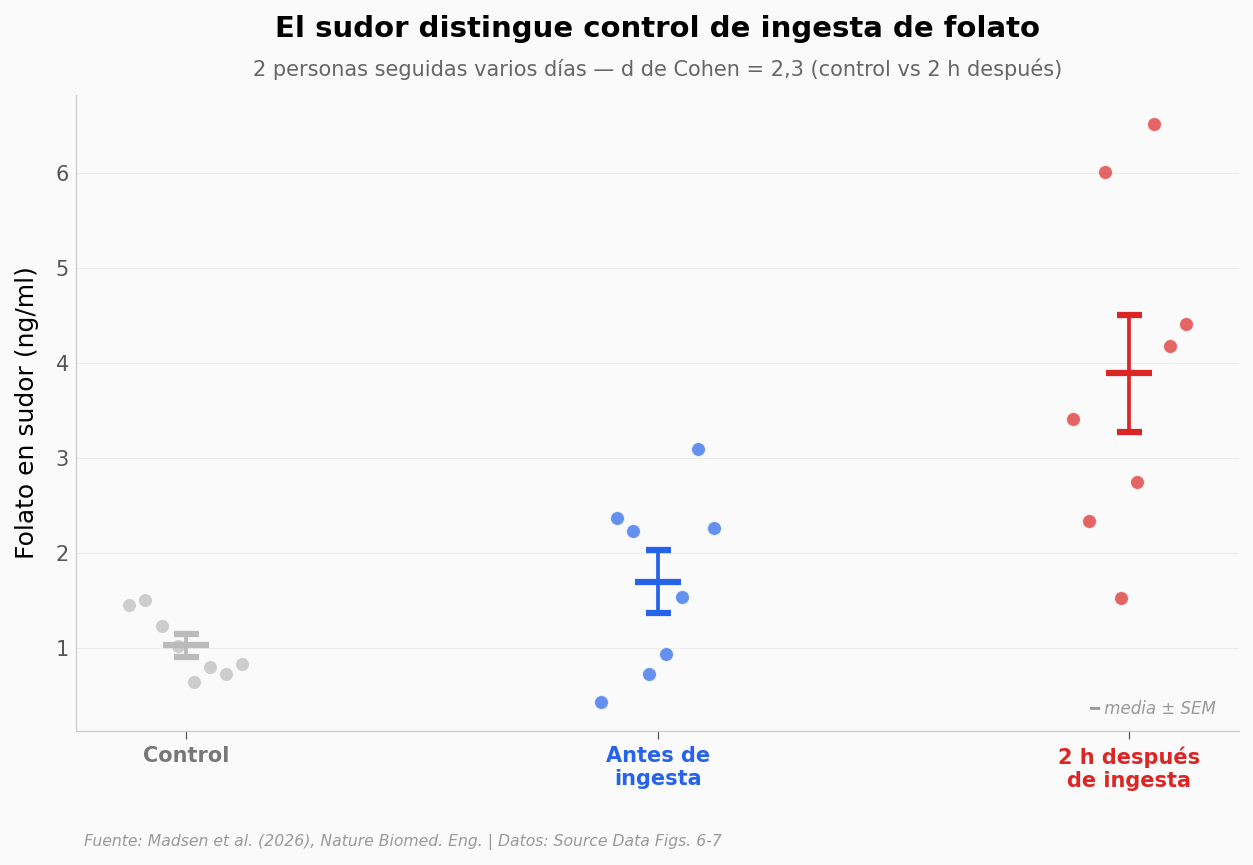

Control 1.02 -> 2h después 3.89 ng/ml (3.8x) | d de Cohen=2.28


In [4]:
np.random.seed(42)
phases = ['Control', 'Before intake', '2hr after intake']
labels = ['Control', 'Antes de\ningesta', '2 h después\nde ingesta']
colors = ['#BBBBBB', COLOR_DATOS, COLOR_ALERTA]
positions = [0, 1, 2]

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, ph in enumerate(phases):
    vals = seg[seg['phase'] == ph]['sweat_folate_ng_ml'].values
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.12, positions[i] + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=colors[i], s=45, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)
    m = vals.mean(); sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], m, yerr=sem, fmt='_', color=colors[i],
                markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

# Tamaño de efecto (d de Cohen) control vs 2 h después. NO p-value:
# solo 2 personas seguidas día a día -> describir el salto, no testear.
c = seg[seg['phase'] == 'Control']['sweat_folate_ng_ml']
a = seg[seg['phase'] == '2hr after intake']['sweat_folate_ng_ml']
psd = np.sqrt(((len(c)-1)*c.std(ddof=1)**2 + (len(a)-1)*a.std(ddof=1)**2) / (len(c)+len(a)-2))
d = (a.mean() - c.mean()) / psd

ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), ['#777777', COLOR_DATOS, COLOR_ALERTA]):
    tick.set_color(color)
ax.set_ylabel('Folato en sudor (ng/ml)')
ax.set_title('El sudor distingue control de ingesta de folato',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'2 personas seguidas varios días — d de Cohen = {cc(d,1)} (control vs 2 h después)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/control_vs_ingesta.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Control {c.mean():.2f} -> 2h después {a.mean():.2f} ng/ml ({a.mean()/c.mean():.1f}x) | d de Cohen={d:.2f}')

## ¿Y el aparato es de fiar?

Todo lo anterior sale del mismo *lab-on-a-disc* portátil. La prueba de fuego: medir las mismas muestras con el disco **y** con un ELISA de placa de laboratorio — el método de referencia — y ver qué tan cerca quedan.

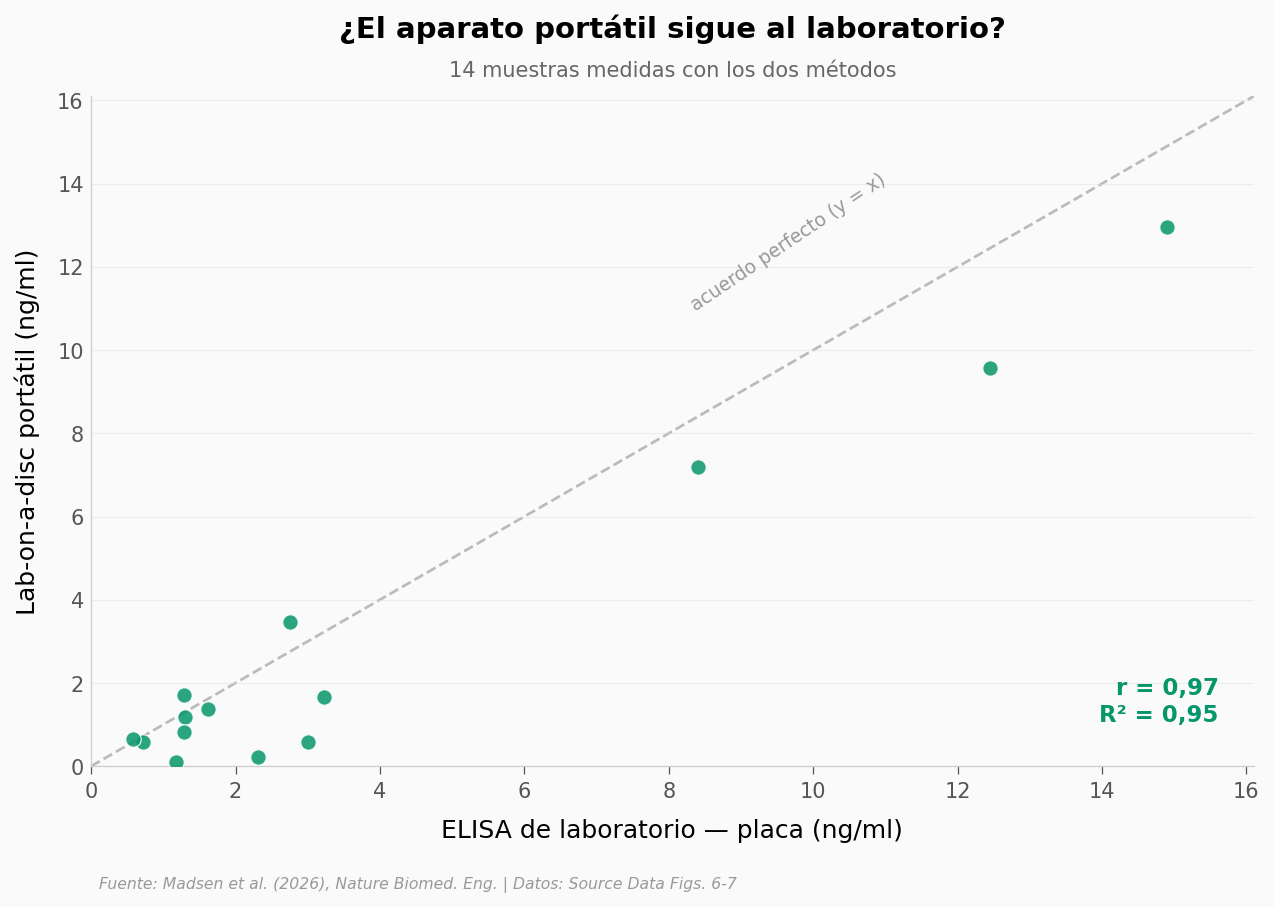

Disco vs ELISA de placa: r=0.975, R2=0.951, n=14


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.8))
xd = val['plate_elisa_ng_ml']
yd = val['lab_on_disc_ng_ml']
r_v, _ = stats.pearsonr(xd, yd)

lims = [0, max(xd.max(), yd.max()) * 1.08]
ax.plot(lims, lims, color='#BBBBBB', lw=1.3, ls='--', zorder=1)
ax.text(lims[1]*0.60, lims[1]*0.68, 'acuerdo perfecto (y = x)',
        fontsize=9, color='#999999', rotation=34, ha='center')
ax.scatter(xd, yd, color=COLOR_SECUNDARIO, s=55, alpha=0.85,
           edgecolors='white', linewidths=0.6, zorder=5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('ELISA de laboratorio — placa (ng/ml)')
ax.set_ylabel('Lab-on-a-disc portátil (ng/ml)')
ax.set_title('¿El aparato portátil sigue al laboratorio?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '14 muestras medidas con los dos métodos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.97, 0.06, f'r = {cc(r_v)}\nR² = {cc(r_v**2)}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', color=COLOR_SECUNDARIO, ha='right', va='bottom')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/validacion_dispositivo.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Disco vs ELISA de placa: r={r_v:.3f}, R2={r_v**2:.3f}, n={len(val)}')

Los puntos caen casi sobre una recta — r = 0,97, las dos medidas se mueven juntas. Pero fíjate en la línea punteada: en las concentraciones altas el disco queda **por debajo** del acuerdo perfecto, o sea lee un poco más bajo que la placa de laboratorio. Una correlación casi perfecta dice que el disco *sigue* fielmente al laboratorio; para soltar un número clínico exacto habría que calibrar esa diferencia de escala. Sigue la tendencia de maravilla; le falta calibración.

## El folato en el sudor real

Una última mirada: ¿dónde caen los valores cuando juntamos todas las mediciones de sudor del estudio?

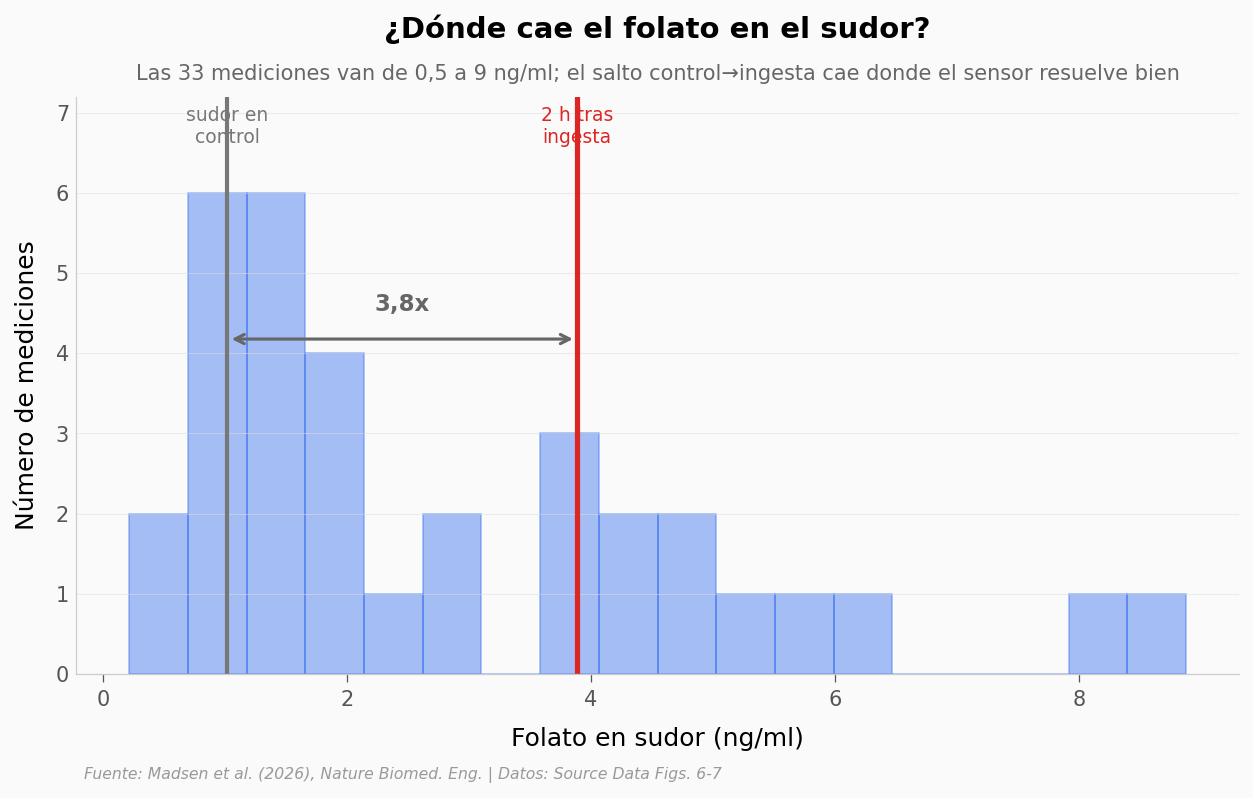

Sudor en control 1.02 -> 2h tras ingesta 3.89 ng/ml


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sweat_all = corr['sweat_folate_ng_ml'].values
n_b, bins, patches = ax.hist(sweat_all, bins=18, color=COLOR_DATOS, alpha=0.4,
                             edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n_b.max() * 1.20
ax.set_ylim(0, y_max)

control_m = seg[seg['phase'] == 'Control']['sweat_folate_ng_ml'].mean()
intake_m  = seg[seg['phase'] == '2hr after intake']['sweat_folate_ng_ml'].mean()
ax.axvline(control_m, color='#777777', lw=2)
ax.axvline(intake_m, color=COLOR_ALERTA, lw=2.5)
ax.annotate('', xy=(intake_m, y_max*0.58), xytext=(control_m, y_max*0.58),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((control_m + intake_m)/2, y_max*0.63, f'{cc(intake_m/control_m,1)}x', ha='center',
        fontsize=11, fontweight='bold', color='#666666')
ax.text(control_m, y_max*0.92, 'sudor en\ncontrol', ha='center', fontsize=9, color='#777777')
ax.text(intake_m, y_max*0.92, '2 h tras\ningesta', ha='center', fontsize=9, color=COLOR_ALERTA)
ax.set_xlabel('Folato en sudor (ng/ml)')
ax.set_ylabel('Número de mediciones')
ax.set_title('¿Dónde cae el folato en el sudor?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las 33 mediciones van de 0,5 a 9 ng/ml; el salto control→ingesta cae donde el sensor resuelve bien',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_sudor.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Sudor en control {control_m:.2f} -> 2h tras ingesta {intake_m:.2f} ng/ml')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El folato en sudor correlaciona fuerte con el de suero | ✅ | Spearman ρ = 0,81 (Pearson r = 0,84; R² = 0,70), 33 pares de 7 personas, p < 0,001. Spearman porque los datos no son normales (Shapiro p < 0,01). |
| El suero tiene ~10x más folato que el sudor | ✅ | Razón de medias 9,96. Por eso hace falta un sensor de alta sensibilidad. |
| Tras la ingesta, el folato hace pico a la 1–2 h en sudor y suero | ✅ | Promedio de 5 personas; máximo a la 1 h y alto hasta la 2 h en ambos fluidos. |
| El sudor distingue control de ingesta | ⚠️ | Salto de ~1,0 a ~3,9 ng/ml (3,8x), d de Cohen = 2,3. Pero **solo 2 personas** seguidas día a día: es descriptivo, no un test poblacional. El paper reporta significancia (Wilcoxon p = 0,008) sobre su cohorte completa. |
| El disco portátil sigue al ELISA de laboratorio | ✅ | r = 0,97 (R² = 0,95), 14 muestras con ambos métodos. Correlación casi perfecta, pero el disco lee algo más bajo en concentraciones altas: sigue bien la tendencia, requiere calibración para un número clínico exacto. |
| El sensor cubre un rango de 400x (0,5–200 ng/ml) | ✅ | Curva de calibración de 7 puntos. |

> **Limitaciones:** (1) Cohorte de **7 adultos sanos, ninguna embarazada** — lo *prenatal* es la meta a futuro, no algo validado aquí. (2) El seguimiento diario es de **solo 2 personas**: el salto control→ingesta es claro pero no tiene poder estadístico. (3) Correlación sudor~suero no significa que el sudor reemplace al análisis de sangre para decisiones clínicas; mide biodisponibilidad, no diagnóstico. (4) Datos de un único laboratorio y dispositivo.

## Ahora tú

1. **¿Qué tan lineal es la relación sudor–suero?** Ajusta una recta a los 33 puntos y mira la pendiente. *Pista: `np.polyfit(corr.serum_folate_ng_ml, corr.sweat_folate_ng_ml, 1)`.*
2. **¿El pico depende de la persona?** Grafica la cinética de cada sujeto por separado en vez del promedio. *Pista: `for s in cin.subject.unique(): ...`.*
3. **¿Cuánto error tolera el disco?** Calcula el error absoluto medio entre el disco y el ELISA de placa. *Pista: `(val.lab_on_disc_ng_ml - val.plate_elisa_ng_ml).abs().mean()`.*

In [7]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto sube el folato en sudor por cada unidad de folato en suero?
x = corr['serum_folate_ng_ml'].values
y = corr['sweat_folate_ng_ml'].values
pendiente, interseccion = np.polyfit(x, y, 1)
print(f'sudor ≈ {pendiente:.3f} × suero + {interseccion:.2f}')
print(f'Por cada 10 ng/ml más de folato en suero, el sudor sube ~{pendiente*10:.2f} ng/ml')
# Prueba: cambia el grado del ajuste a 2 y mira si mejora el patrón.

sudor ≈ 0.076 × suero + 0.70
Por cada 10 ng/ml más de folato en suero, el sudor sube ~0.76 ng/ml


## Créditos y reproducibilidad

Datos: **Source Data Figs. 6–7** del paper (mismo DOI). Notebook reproducible — corre en Colab o local con `pandas`, `matplotlib`, `numpy`, `scipy`.

- **Paper:** Madsen et al. (2026), *Nature Biomedical Engineering* — [DOI: 10.1038/s41551-026-01716-5](https://doi.org/10.1038/s41551-026-01716-5)
- **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Licencia datos:** según Source Data del editor.

## Fuentes

**Paper**: [Skin-interfaced microfluidic capsule and portable lab-on-a-disc platform for sweat-based monitoring of prenatal nutrient balance](https://doi.org/10.1038/s41551-026-01716-5)  
*Nature Biomedical Engineering, 2026-06-17*

**Source Data**: [Source Data Figs. 6–7 (mismo DOI)](https://doi.org/10.1038/s41551-026-01716-5)

*12 afirmaciones del notebook verificadas contra estas fuentes*